In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop
import pdb
import time

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [2]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20',
                                                     "kick_mean_ns":350, "kick_mean_bh":100}, # IFMR + kick velocities
                                {"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()

 13520 - Execution Date: 30-09-2025 10:13:00


################################ Settings #################################
 13565 - # reading default parameters from
 13567 - default_config_file =  /u/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 13699 - # read configuration from 
 13700 - config_file = '/u/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 13725 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1057816395,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,

Then, run the specific sightline you want

In [12]:
t0=time.time()
_ = sp_mod.process_location(1, -1.2, # first, enter l and b in degrees
                            solid_angle=1e-2, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing
print(f'Synthpop catalog generated in {np.round((time.time()-t0)/60, 2)} minutes.')



############################# update location #############################
 314914 - # set location to: 
 314916 - l, b = (1.00 deg, -1.20 deg)
 314917 - # set solid_angle to:
 314919 - solid_angle = 1.000e-02 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 318219 - # From density profile (number density)
 318221 - expected_total_iMass = 4044785.8715
 318223 - expected_total_eMass = 2204133.1699
 318225 - average_iMass_per_star = 0.5739
 318227 - mass_loss_correction = 0.5449
 318230 - n_expected_stars = 7048311.2816
 318236 - # Determine velocities when position are generated 


  0%|          | 0/7046743 [00:00<?, ?it/s]

 477985 - # From Generated Field:
 477987 - generated_stars = 7046743
 478100 - generated_total_iMass = 4054950.7356
 478497 - generated_total_eMass = 2209903.8501
 478679 - det_mass_loss_corr = 0.5450
 489084 - # Done


# Population 1;  halo -----------------------------------------------------
 490911 - # From density profile (number density)
 490914 - expected_total_iMass = 5358.2615
 490916 - expected_total_eMass = 2817.6454
 490919 - average_iMass_per_star = 0.5739
 490921 - mass_loss_correction = 0.5259
 490923 - n_expected_stars = 9337.1309
 490929 - # Determine velocities when position are generated 
 491400 - # From Generated Field:
 491403 - generated_stars = 9309
 491405 - generated_total_iMass = 5390.1442
 491415 - generated_total_eMass = 2797.5096
 491418 - det_mass_loss_corr = 0.5190
 491497 - # Done


# Population 2;  nsd ------------------------------------------------------
 493659 - # From density profile (number density)
 493662 - expected_total_iMass = 21004.3518
 4

  0%|          | 0/486978 [00:00<?, ?it/s]

 593265 - # From Generated Field:
 593267 - generated_stars = 486978
 593276 - generated_total_iMass = 279356.2157
 593311 - generated_total_eMass = 151664.9846
 593326 - det_mass_loss_corr = 0.5429
 594108 - # Done


########################### Combine Populations ###########################
 597182 - Number of stars generated: 8156415 (34 columns)
 597185 - included_columns = ['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Bessell_U', 'Bessell_B', 'Bessell_V', 'Bessell_R', 'Bessell_I', '2MASS_J', '2MASS_H', '2MASS_Ks']
 649951 - ---------------------------------------------------------------



PopSyCLE formatted output saved in synthpop_output/synthpopsycle_l1.000_b-1.200_psc.h5
Synthpop catalog generated in 5.58 minutes.


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [13]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_l1.000_b-1.200_psc.h5", 
                      output_root2 = 'synthpop_output/synthpopsycle_l1.000_b-1.200_psc', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = True, 
                      n_proc = 4)

Working on loop ll, bb =  0 2
Working on loop ll, bb =  0 3
Working on loop ll, bb =  2 2
Working on loop ll, bb =  2 3
Working on loop ll, bb =  4 0
Working on loop ll, bb =  4 1
Working on loop ll, bb =  0 0
Working on loop ll, bb =  0 1
Working on loop ll, bb =  1 3
Working on loop ll, bb =  1 4
Working on loop ll, bb =  3 1
Working on loop ll, bb =  3 2
Working on loop ll, bb =  0 4
Working on loop ll, bb =  1 0
Working on loop ll, bb =  2 0
Working on loop ll, bb =  2 1
Working on loop ll, bb =  3 3
Working on loop ll, bb =  3 4
Working on loop ll, bb =  4 4
Working on loop ll, bb =  1 1
Working on loop ll, bb =  1 2
Working on loop ll, bb =  2 4
Working on loop ll, bb =  3 0
Working on loop ll, bb =  4 2
Working on loop ll, bb =  4 3
Candidate events detected:  1424
calc_events runtime : 440.335840 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [14]:
synthetic.refine_events(input_root = 'synthpop_output/synthpopsycle_l1.000_b-1.200_psc', 
                        filter_dict={'ubv':['I']},
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  1113
Candidate events in survey window:  983
refine_events runtime : 2.282272 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [15]:
t = Table.read('synthpop_output/synthpopsycle_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'ubv_U_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'ubv_I_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'obj_id_L', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'ubv_U_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'ubv_I_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'obj_id_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [16]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 19
Number of NSs: 18
Number of WDs: 145
Number of stars: 801


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

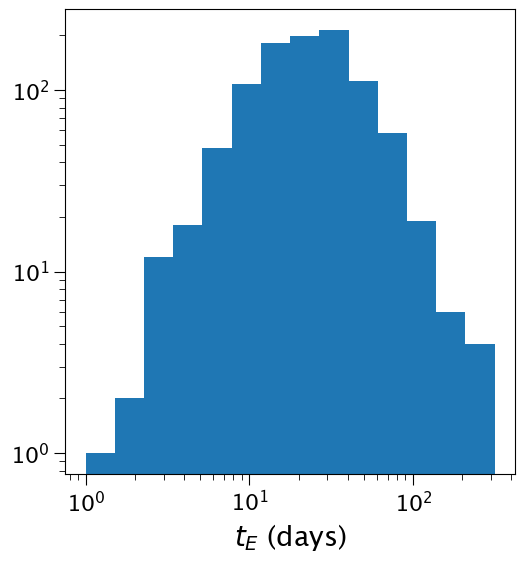

In [17]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

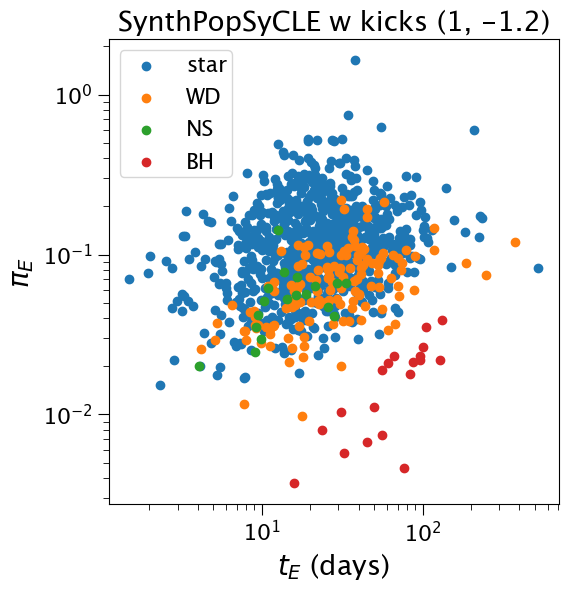

In [18]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (1, -1.2)')
plt.savefig('synthpopsycle_lenstype.png')

## dL vs dS

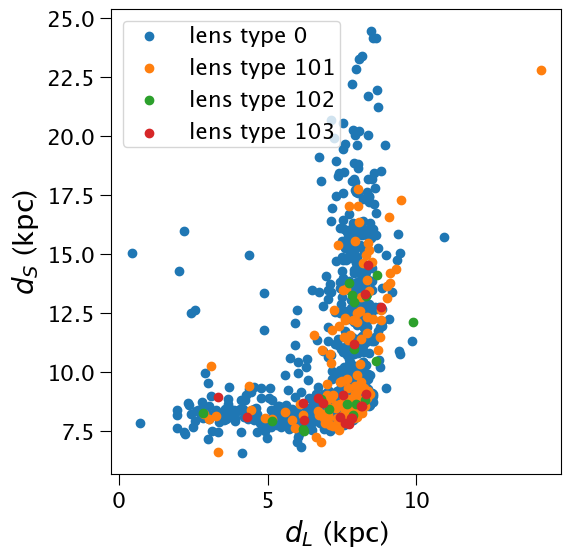

In [19]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()